In [3]:
import warnings
warnings.filterwarnings('ignore')
import fastf1
import fastf1.plotting
import seaborn as sns
import matplotlib.pyplot as plt

# Enable the dark theme for F1 plots
fastf1.plotting.setup_mpl(misc_mpl_mods=False)

# Create a folder for the cache
import os
os.makedirs('data/cache', exist_ok=True)
fastf1.Cache.enable_cache('data/cache')

In [4]:
# Year: 2026, Test: 2, Day: 3
session = fastf1.get_testing_session(2026, 2, 3)
session.load()

# Get the fastest lap from Ferrari
lec_lap = session.laps.pick_driver('LEC').pick_fastest()
telemetry = lec_lap.get_telemetry().add_distance()

print(f"Loaded {lec_lap['Driver']}'s fastest lap: {lec_lap['LapTime']}")

core           INFO 	Loading data for Pre-Season Testing - Practice 3 [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Fixed incorrect tyre stint information for driver '1'
core        WARNING 	Fixed incorrect tyre stint information for driver '3'
core        WARNING 	Fixed incorrect tyre stint information for driver '5'
core        WARNING 	Fixed incorrect tyre stint information for driver '6'
core        WARNING 	Fixed incorrect tyre stint information for driver '10'
core        WARNING 	No lap data for driver 14
core        WARNING 	Fixed incorrect tyre stint information for driver '16'
core        WARN

Loaded LEC's fastest lap: 0 days 00:01:31.992000


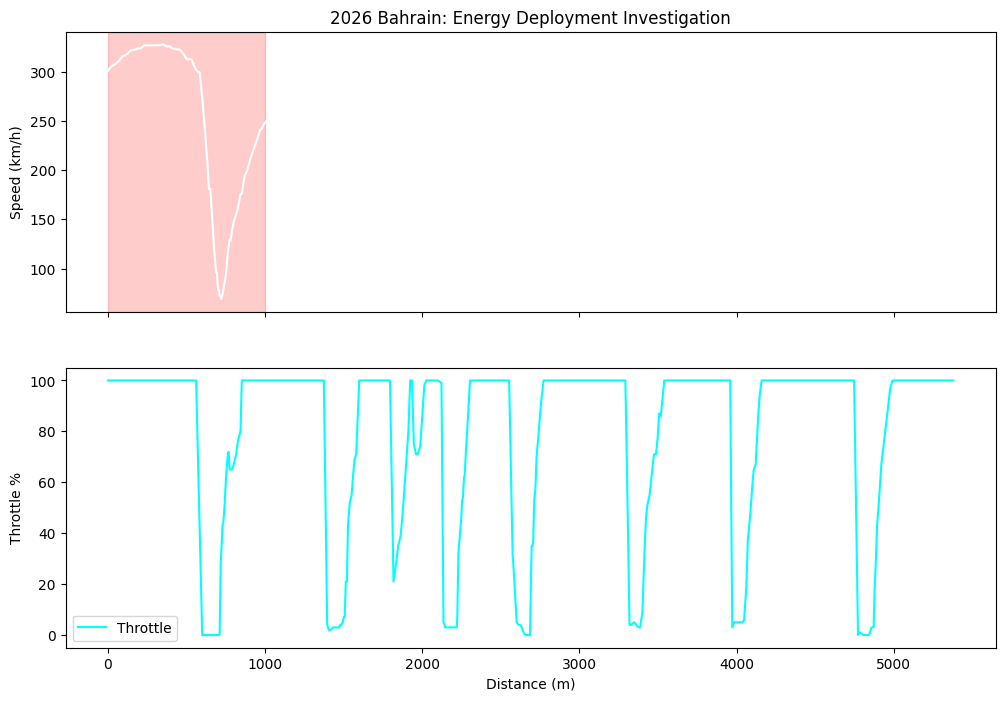

In [5]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Panel 1: Speed
ax[0].plot(telemetry['Distance'], telemetry['Speed'], label='Speed', color='white')
ax[0].set_ylabel('Speed (km/h)')
ax[0].set_title('2026 Bahrain: Energy Deployment Investigation')

# Panel 2: Throttle
ax[1].plot(telemetry['Distance'], telemetry['Throttle'], label='Throttle', color='cyan')
ax[1].set_ylabel('Throttle %')
ax[1].set_xlabel('Distance (m)')

# Let's highlight a known straight (e.g., the main straight in Bahrain)
ax[0].axvspan(0, 1000, color='red', alpha=0.2, label='Potential Clipping Zone')

plt.legend()
plt.show()